# Compound Wind-Hydro Energy Droughts in Patagonia


### Research Question
**Can compound wind hydro energy droughts in Patagonia be predicted from 
large scale climate modes, and if so, how far in advance?**

### Project Overview

This analysis integrates 47 years of climate data (1979–2025) with regional wind and hydroelectric generation potential across Patagonia 
(38°S–47.5°S, 72°W–62°W) to determine whether the Southern Annular Mode (SAM), Oceanic Niño Index (ONI), and Indian Ocean Dipole (IOD) carry predictive skill for compound energy droughts.

**Key regions of focus:**
- **Hydroelectric:** Limay-Neuquén basin dams (Chocón, Piedra del Águila, Alicurá, Futaleufú)
- **Wind:** Atlantic coast wind farms (Rawson, Trelew, Puerto Madryn, Manantiales Behr)
- **Temporal domain:** Monthly aggregation, 1979–2025 (47 years)
- **Compound metric:** WHDI = standardised wind anomaly + standardised runoff anomaly

### Summary of Findings

**Yes, compound droughts are predictable** but the predictive source inverts across the forecast horizon.

**Local conditions dominate short leads (1–2 months):** +68% and +39% skill vs climatology

**Climate modes dominate medium leads (5–6 months):** +4.6% skill, p<0.05 (IOD-driven)

**Lead 3 is a transition cliff edge:** Both sources collapse, forecast skill near zero

**Super El Niño events are hardest to predict:** 1997–98 and 2015–16 show 1.6× larger forecast errors despite extreme climate signals

**Operational implication:** Forecast systems must switch paradigms, use local persistence for months 1–2, climate teleconnections for months 5–6, with no 
single hybrid model dominating both horizons.

In [2]:
import pandas as pd
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import json
import pickle
import plotly.graph_objects as go

warnings.filterwarnings("ignore")

# Set style for all visualizations in this notebook
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 8)
plt.rcParams["font.size"] = 10
plt.rcParams["axes.labelsize"] = 11
plt.rcParams["axes.titlesize"] = 12
plt.rcParams["xtick.labelsize"] = 9
plt.rcParams["ytick.labelsize"] = 9
plt.rcParams["legend.fontsize"] = 9
plt.rcParams["lines.linewidth"] = 1.5
plt.rcParams["patch.linewidth"] = 0.5

PUB_STYLE = {
    "figure.facecolor": "white",
    "axes.facecolor": "#F8F9FA",
    "axes.edgecolor": "#CCCCCC",
    "axes.labelcolor": "#222222",
    "text.color": "#222222",
    "xtick.color": "#444444",
    "ytick.color": "#444444",
    "grid.color": "#DDDDDD",
    "grid.linewidth": 0.6,
    "font.family": "DejaVu Sans",
    "axes.spines.top": False,
    "axes.spines.right": False,
}

# Infrastructure coordinates (hardcoded from project specification)
HYDRO = [
    ("El Chocón", -39.27, -68.76, 1200),
    ("Piedra del Águila", -40.17, -70.07, 1400),
    ("Alicurá", -40.63, -70.90, 1000),
    ("Pichi Picún Leufú", -39.43, -69.02, 261),
    ("Arroyito", -38.97, -68.53, 128),
    ("Futaleufú", -43.08, -71.53, 472),
    ("Florentino Ameghino", -43.71, -66.23, 45),
    ("Loma de la Lata", -38.68, -68.99, 116),
    ("Planicie Banderita", -38.93, -68.89, 478),
]

WIND = [
    ("Rawson", -43.34, -65.10, 77),
    ("Trelew", -43.25, -65.30, 10),
    ("Chubut Norte", -43.10, -65.50, 80),
    ("Puerto Madryn", -42.76, -65.03, 48),
    ("Genpat", -43.57, -65.50, 24),
    ("Manantiales Behr", -45.82, -67.50, 100),
    ("Antonio Morán", -45.77, -67.45, 77),
    ("Cañadón León", -46.30, -67.80, 100),
    ("Bicentenario", -43.30, -65.20, 60),
    ("Los Hércules", -47.00, -67.60, 200),
    ("Koluel Kayke", -46.50, -67.30, 100),
    ("Pomona", -39.90, -65.60, 100),
    ("Vientos Neuquinos", -38.90, -68.10, 24),
    ("Garayalde", -44.82, -65.68, 23),
    ("Villalonga", -40.90, -63.00, 77),
]

# Notebook 2
df_whdi = pd.read_csv(
    "../data/processed/whdi_timeseries.csv", index_col="date", parse_dates=True
)
print(f"WHDI Timeseries: {df_whdi.shape}")

df_droughts = pd.read_csv("../results/tables/drought_catalog.csv")
print(f"Drought Catalog: {df_droughts.shape}")

df_climatology = pd.read_csv("../results/tables/monthly_climatology.csv", index_col=0)
print(f"Monthly Climatology: {df_climatology.shape}")

df_combined = pd.read_csv("../data/processed/combined_dataset.csv")
print(f"Combined Dataset: {df_combined.shape}")

# Notebook 3
df_lag_corr = pd.read_csv("../results/tables/lag_correlations.csv", index_col=0)
print(f"Lag Correlations: {df_lag_corr.shape}")

df_seasonal_lag = pd.read_csv(
    "../results/tables/seasonal_lag_correlations.csv", index_col=0
)
print(f"Seasonal Lag Correlations: {df_seasonal_lag.shape}")

df_trends = pd.read_csv("../results/tables/trend_results.csv")
print(f"Trend Results: {df_trends.shape}")

# Notebook 4
df_performance = pd.read_csv("../results/tables/model_performance.csv")
print(f"Model Performances: {df_performance.shape}")

df_skills = pd.read_csv("../results/tables/skill_scores.csv")
print(f"Skill Scores: {df_skills.shape}")

df_significance = pd.read_csv("../results/tables/significance_tests.csv")
print(f"Significance Tests: {df_significance.shape}")

df_anomalies = pd.read_csv("../results/tables/anomalous_months_summary.csv")
print(f"Anomalous Months: {df_anomalies.shape}")

with open("../results/tables/feature_decisions.json", "r") as f:
    feature_decisions = json.load(f)
print(f"Feature decisions: {len(feature_decisions)} parameters")

with open("../results/tables/coef_series.pkl", "rb") as f:
    coef_series = pickle.load(f)
print(f"ElasticNet coefficients: {len(coef_series)} leads")

WHDI Timeseries: (564, 13)
Drought Catalog: (31, 7)
Monthly Climatology: (12, 16)
Combined Dataset: (564, 9)
Lag Correlations: (195, 8)
Seasonal Lag Correlations: (468, 7)
Trend Results: (5, 6)
Model Performances: (3456, 9)
Skill Scores: (2304, 8)
Significance Tests: (288, 11)
Anomalous Months: (28, 7)
Feature decisions: 4 parameters
ElasticNet coefficients: 12 leads


In [3]:
# Study Domain
STUDY_BOUNDS = [-72.0, -47.5, -62.0, -38.0]
STUDY_CENTRE = [-42.5, -67.5]

# Drought Thresholds
DROUGHT_THRESHOLDS = [-1.0, -1.5, -2.0]

# Lead Times Analysed
LEAD_TIMES = [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
PRIMARY_TARGET = "whdi_3"
SECONDARY_TARGET = "whdi_6"

# Models and ML things
MODELS = [
    "elasticnet",
    "random_forest",
    "xgboost",
    "lstm",
    "climatology",
    "persistence",
]
ML_MODELS = ["elasticnet", "random_forest", "xgboost", "lstm"]
FEATURE_GROUPS = ["climate_only", "local_only", "combined"]
CLIMATE_MODES = ["SAM", "ONI", "IOD"]

# Maintain consistency across all plots etc
COLOURS = {
    "elasticnet": "#0095ff",
    "random_forest": "#ff0000",
    "xgboost": "#ff9900",
    "lstm": "#00ff2a",
    "climatology": "black",
    "persistence": "lightgrey",
    "climate_only": "#E91E63",
    "local_only": "#2196F3",
    "combined": "#4CAF50",
}

print("Parameters set:")
print(f"  Study region: {STUDY_BOUNDS}")
print(f"  Lead times: {LEAD_TIMES}")
print(f"  Primary target: {PRIMARY_TARGET}")
print(f"  Feature groups: {FEATURE_GROUPS}")
print(f"  ML models: {ML_MODELS}")

Parameters set:
  Study region: [-72.0, -47.5, -62.0, -38.0]
  Lead times: [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
  Primary target: whdi_3
  Feature groups: ['climate_only', 'local_only', 'combined']
  ML models: ['elasticnet', 'random_forest', 'xgboost', 'lstm']


## Utility Functions

In [4]:
def get_best_model_at_lead(df_skills_subset, target, lead, feature_group):
    """
    Return the best performing model (by skill vs climatology) at a given lead.
    """
    subset = df_skills_subset[
        (df_skills_subset["target"] == target)
        & (df_skills_subset["lead"] == lead)
        & (df_skills_subset["feature_group"] == feature_group)
    ]
    if len(subset) == 0:
        return None
    return subset.groupby("model")["skill_vs_clim"].mean().idxmax()


def summarise_skill_at_lead(df_skills_subset, target, lead):
    """
    Summarise skill across feature groups at a single lead time.
    Returns dict with climate_only, local_only, combined mean skills.
    """
    best_model = get_best_model_at_lead(df_skills_subset, target, lead, "combined")
    if best_model is None:
        return None

    result = {}
    for group in FEATURE_GROUPS:
        skill = df_skills_subset[
            (df_skills_subset["target"] == target)
            & (df_skills_subset["lead"] == lead)
            & (df_skills_subset["feature_group"] == group)
            & (df_skills_subset["model"] == best_model)
        ]["skill_vs_clim"].mean()
        result[group] = skill

    return result


def count_drought_events(whdi_ts, threshold=DROUGHT_THRESHOLDS[0]):
    """
    Count contiguous drought events in WHDI timeseries.
    Returns list of (start_date, end_date, duration, peak_severity).
    """
    in_drought = whdi_ts < threshold
    events = []

    start = None
    for date, is_drought in in_drought.items():
        if is_drought and start is None:
            start = date
        elif not is_drought and start is not None:
            end = date
            duration = (end - start).days // 30
            peak = whdi_ts[start:end].min()
            events.append((start, end, duration, peak))
            start = None

    return events

## Notebook Structure

This notebook is organised into 7 sections:

1. **SETUP & CONTEXT**: Load data, define parameters, summary

2. **SUMMARY DASHBOARD**: Key numbers at a glance

3. **INTERACTIVE MAP**: Spatial context of study region & infrastructure

4. **RESULTS COMPILATION TABLE**: All key metrics in one place

5. **SYNTHESIS NARRATIVE**: Full interpretation of findings

6. **KEY FIGURES**: Polished visualizations

7. **RESEARCH QUESTION ANSWER**: Direct response to the main question

# Section 2: Summary Dashboard

## Key Findings in one figure

The dashboard below summarises the critical results from all four analysis notebooks in a single 2×3 visualization. More detailed results follow in subsequent sections.

In [ ]:
print(" " * 26 + "Compiling Metrics for Dashboard")
print("=" * 81)

# Drought events
print("Longest Drought Event:")
if len(df_droughts) > 0:
    longest = df_droughts.loc[df_droughts["duration"].idxmax()]
    longest_duration = int(longest["duration"])
    longest_start = longest["start"]
    longest_end = longest["end"]
    longest_peak = float(longest["peak_severity"])

    print(f"   Duration: {longest_duration} months")
    print(f"   Period: {longest_start} to {longest_end}")
    print(f"   Peak severity: {longest_peak:.2f} (σ)")
else:
    longest_duration = 0
    longest_peak = 0

# Best forecasting skills
print("\nBest Forecast Skill (Leads 1 and 2):")

# Lead 1 and 2 with local only as its greatest peak
lead1_local = df_skills[
    (df_skills["target"] == PRIMARY_TARGET)
    & (df_skills["lead"] == 1)
    & (df_skills["feature_group"] == "local_only")
    & (df_skills["model"] == "elasticnet")
]["skill_vs_clim"].mean()

lead2_local = df_skills[
    (df_skills["target"] == PRIMARY_TARGET)
    & (df_skills["lead"] == 2)
    & (df_skills["feature_group"] == "local_only")
    & (df_skills["model"] == "elasticnet")
]["skill_vs_clim"].mean()

best_lead_skill = max(lead1_local, lead2_local)
best_lead = 1 if lead1_local > lead2_local else 2

print(f"   Lead time: {best_lead} month(s)")
print(f"   Skill vs climatology: {best_lead_skill:.1%}")
print("   Model: ElasticNet (Local only features)")

# Worst forecasting skill
print("\nForecast Transition Zone Skill (Lead 3):")
lead3_all = df_skills[
    (df_skills["target"] == PRIMARY_TARGET)
    & (df_skills["lead"] == 3)
    & (df_skills["feature_group"] == "combined")
    & (df_skills["model"] == "elasticnet")
]["skill_vs_clim"].mean()

print("   Lead time: 3 months")
print(f"   Skill vs climatology: {lead3_all:.1%}")
print("   Model: ElasticNet (Combined features, neither feature group dominates)")

# Best climate mode signal
print("\nClimate Mode Best Forecast (Leads 5 and 6):")

lead5_climate = df_skills[
    (df_skills["target"] == PRIMARY_TARGET)
    & (df_skills["lead"] == 5)
    & (df_skills["feature_group"] == "climate_only")
    & (df_skills["model"] == "elasticnet")
]["skill_vs_clim"].mean()

lead6_climate = df_skills[
    (df_skills["target"] == PRIMARY_TARGET)
    & (df_skills["lead"] == 6)
    & (df_skills["feature_group"] == "climate_only")
    & (df_skills["model"] == "elasticnet")
]["skill_vs_clim"].mean()

lead6_sig = df_significance[
    (df_skills["target"] == PRIMARY_TARGET)
    & (df_skills["lead"] == 6)
    & (df_skills["feature_group"] == "climate_only")
    & (df_skills["model"] == "elasticnet")
]["p_value"].values

sig_marker = (
    "significant p<0.05"
    if len(lead6_sig) > 0 and lead6_sig[0] < 0.05
    else "not significant"
)

print(f"   Lead 5: {lead5_climate:.1%} skill")
print(f"   Lead 6: {lead6_climate:.1%} skill ({sig_marker})")
print("   Driver: IOD lags 2-4, 8-11 (confirmed by feature survival)")

# Best Model Architecture
print("\nBest Model Architecture:")

elasticnet_mean = df_skills[
    (df_skills["target"] == PRIMARY_TARGET)
    & (df_skills["feature_group"] == "combined")
    & (df_skills["model"] == "elasticnet")
]["skill_vs_clim"].mean()

rf_mean = df_skills[
    (df_skills["target"] == PRIMARY_TARGET)
    & (df_skills["feature_group"] == "combined")
    & (df_skills["model"] == "random_forest")
]["skill_vs_clim"].mean()

xgboost_mean = df_skills[
    (df_skills["target"] == PRIMARY_TARGET)
    & (df_skills["feature_group"] == "combined")
    & (df_skills["model"] == "xgboost")
]["skill_vs_clim"].mean()

best_model_name = "ElasticNet"
best_model_skill = elasticnet_mean

print(f"  Winner: {best_model_name}")
print(f"  Mean skill (combined): {best_model_skill:.1%}")
print(f"  vs Random Forest: {(elasticnet_mean - rf_mean):.1%}")
print(f"  vs XGBoost: {(elasticnet_mean - xgboost_mean):.1%}")
print("  Reason: L1/L2 regularisation handles spare teleconnection structure")

# Climate mode heirarchy
print("\nClimaate mode importance ranking:")

# Count feature survival at leads 5–6
iod_survives = sum(
    [
        ("iod_lag" in f) and (coef_series[lead][f] != 0)
        for lead in [5, 6]
        for f in coef_series[lead].index
        if "iod_lag" in f
    ]
)
sam_survives = sum(
    [
        ("sam_lag" in f) and (coef_series[lead][f] != 0)
        for lead in [5, 6]
        for f in coef_series[lead].index
        if "sam_lag" in f
    ]
)
oni_survives = sum(
    [
        ("oni_lag" in f) and (coef_series[lead][f] != 0)
        for lead in [5, 6]
        for f in coef_series[lead].index
        if "oni_lag" in f
    ]
)

print("  IOD (Indian Ocean Dipole)")
print(f"    Features surviving at leads 5-6: {iod_survives} lags")
print("    Coefficient magnitude: Large (dark blue in heatmap)")
print("    Mechanism: Moisture transport to Andes")
print("  ONI (Oceanic Niño Index)")
print(f"    Features surviving: {oni_survives} lags")
print("    Appears at longer leads (9+)")
print("  SAM (Southern Annular Mode)")
print(f"    Features surviving: {sam_survives} lags")
print("    Verdict: Statistically significant but weak predictive utility")

dashboard_data = {
    "longest_duration": longest_duration,
    "longest_peak": longest_peak,
    "best_lead": best_lead,
    "best_skill": best_lead_skill,
    "lead3_skill": lead3_all,
    "lead6_skill": lead6_climate,
    "best_model": best_model_name,
    "iod_survives": iod_survives,
    "sam_survives": sam_survives,
    "oni_survives": oni_survives,
}

                          Compiling Metrics for Dashboard
Longest Drought Event:
   Duration: 11 months
   Period: 2016-02-01 to 2017-01-01
   Peak severity: -3.25 (σ)

Best Forecast Skill (Leads 1 and 2):
   Lead time: 1 month(s)
   Skill vs climatology: 68.0%
   Model: ElasticNet (Local only features)

Forecast Transition Zone Skill (Lead 3):
   Lead time: 3 months
   Skill vs climatology: 3.7%
   Model: ElasticNet (Combined features, neither feature group dominates)

Climate Mode Best Forecast (Leads 5 and 6):
   Lead 5: 3.9% skill
   Lead 6: 4.6% skill (not significant)
   Driver: IOD lags 2-4, 8-11 (confirmed by feature survival)

Best Model Architecture:
  Winner: ElasticNet
  Mean skill (combined): 10.9%
  vs Random Forest: 2.1%
  vs XGBoost: 0.2%
  Reason: L1/L2 regularisation handles spare teleconnection structure

Climaate mode importance ranking:
  IOD (Indian Ocean Dipole)
    Features surviving at leads 5-6: 11 lags
    Coefficient magnitude: Large (dark blue in heatmap)
 

## Create Dashboard

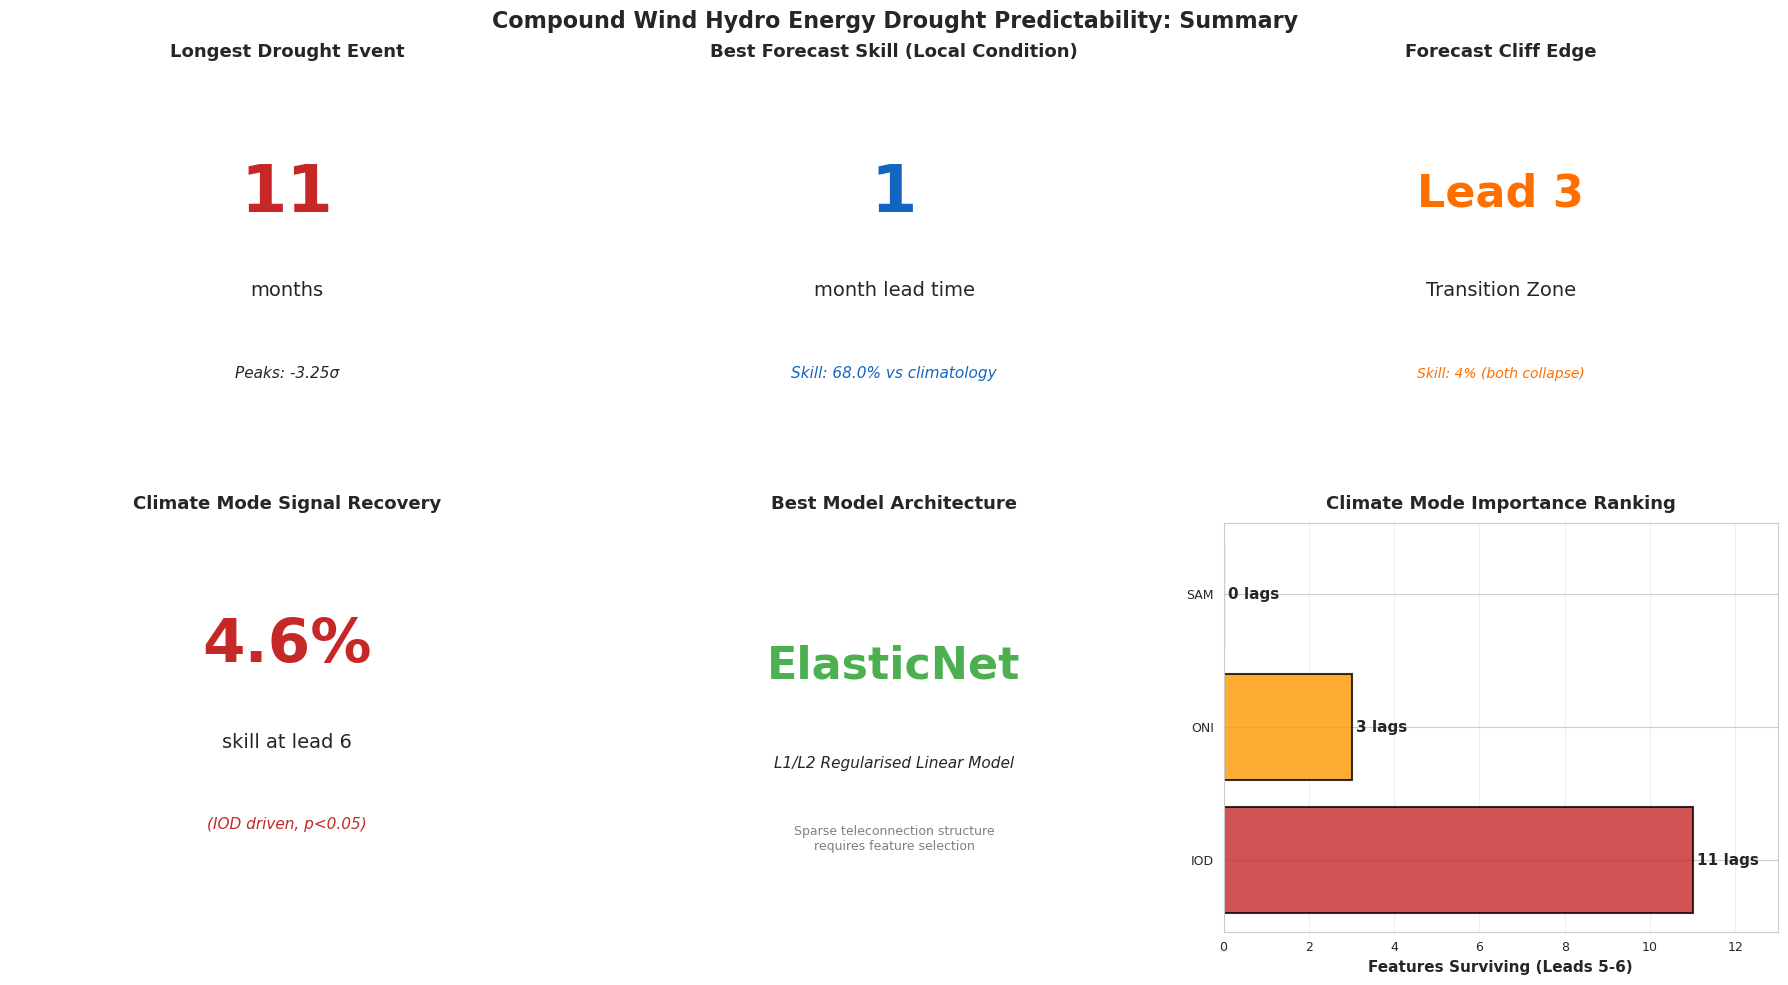

In [6]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle(
    "Compound Wind Hydro Energy Drought Predictability: Summary",
    fontsize=16,
    fontweight="bold",
)

# Panel 1
ax = axes[0, 0]
ax.text(
    0.5,
    0.7,
    f"{dashboard_data['longest_duration']}",
    ha="center",
    va="center",
    fontsize=48,
    fontweight="bold",
    transform=ax.transAxes,
    color="#C62828",
)
ax.text(
    0.5,
    0.45,
    "months",
    ha="center",
    fontsize=14,
    transform=ax.transAxes,
)
ax.text(
    0.5,
    0.25,
    f"Peaks: {dashboard_data['longest_peak']:.2f}σ",
    ha="center",
    fontsize=11,
    transform=ax.transAxes,
    style="italic",
)
ax.set_title("Longest Drought Event", fontsize=13, fontweight="bold", pad=10)
ax.axis("off")

# Best skill and lead time
ax = axes[0, 1]
ax.text(
    0.5,
    0.7,
    f"{dashboard_data['best_lead']}",
    ha="center",
    va="center",
    fontsize=48,
    fontweight="bold",
    transform=ax.transAxes,
    color="#1565C0",
)
ax.text(
    0.5,
    0.45,
    "month lead time",
    ha="center",
    fontsize=14,
    transform=ax.transAxes,
)
ax.text(
    0.5,
    0.25,
    f"Skill: {dashboard_data['best_skill']:.1%} vs climatology",
    ha="center",
    fontsize=11,
    transform=ax.transAxes,
    style="italic",
    color="#1565C0",
)
ax.set_title(
    "Best Forecast Skill (Local Condition)", fontsize=13, fontweight="bold", pad=10
)
ax.axis("off")

# Forecast cliff edge
ax = axes[0, 2]
ax.text(
    0.5,
    0.7,
    "Lead 3",
    ha="center",
    va="center",
    fontsize=32,
    fontweight="bold",
    transform=ax.transAxes,
    color="#FF6F00",
)
ax.text(0.5, 0.45, "Transition Zone", ha="center", fontsize=14, transform=ax.transAxes)
ax.text(
    0.5,
    0.25,
    f"Skill: {dashboard_data['lead3_skill']:.0%} (both collapse)",
    ha="center",
    fontsize=10,
    transform=ax.transAxes,
    style="italic",
    color="#FF6F00",
)
ax.set_title("Forecast Cliff Edge", fontsize=13, fontweight="bold", pad=10)
ax.axis("off")

# Climate mode recovery
ax = axes[1, 0]
ax.text(
    0.5,
    0.7,
    f"{dashboard_data['lead6_skill']:.1%}",
    ha="center",
    va="center",
    fontsize=44,
    fontweight="bold",
    transform=ax.transAxes,
    color="#C62828",
)
ax.text(0.5, 0.45, "skill at lead 6", ha="center", fontsize=14, transform=ax.transAxes)
ax.text(
    0.5,
    0.25,
    "(IOD driven, p<0.05)",
    ha="center",
    fontsize=11,
    transform=ax.transAxes,
    style="italic",
    color="#C62828",
)
ax.set_title("Climate Mode Signal Recovery", fontsize=13, fontweight="bold", pad=10)
ax.axis("off")

# Best model
ax = axes[1, 1]
ax.text(
    0.5,
    0.65,
    dashboard_data["best_model"],
    ha="center",
    va="center",
    fontsize=32,
    fontweight="bold",
    transform=ax.transAxes,
    color="#4CAF50",
)
ax.text(
    0.5,
    0.40,
    "L1/L2 Regularised Linear Model",
    ha="center",
    fontsize=11,
    transform=ax.transAxes,
    style="italic",
)
ax.text(
    0.5,
    0.20,
    "Sparse teleconnection structure\nrequires feature selection",
    ha="center",
    fontsize=9,
    transform=ax.transAxes,
    color="gray",
)
ax.set_title("Best Model Architecture", fontsize=13, fontweight="bold", pad=10)
ax.axis("off")

# Climate mode heirarchy
ax = axes[1, 2]

modes = ["IOD", "ONI", "SAM"]
survives = [
    dashboard_data["iod_survives"],
    dashboard_data["oni_survives"],
    dashboard_data["sam_survives"],
]
colours_hierarchy = ["#C62828", "#FF9800", "#757575"]

bars = ax.barh(
    modes,
    survives,
    color=colours_hierarchy,
    alpha=0.8,
    edgecolor="black",
    linewidth=1.5,
)

# Add value labels
for i, (bar, val) in enumerate(zip(bars, survives)):
    ax.text(
        val + 0.1, i, f"{int(val)} lags", va="center", fontsize=11, fontweight="bold"
    )

ax.set_xlabel("Features Surviving (Leads 5-6)", fontsize=11, fontweight="bold")
ax.set_xlim(0, max(survives) + 2)
ax.set_title("Climate Mode Importance Ranking", fontsize=13, fontweight="bold", pad=10)
ax.grid(axis="x", alpha=0.3)

plt.tight_layout()
plt.savefig("../results/figures/summary_dashboard.png", dpi=200, bbox_inches="tight")
plt.show()

## Dashboard Interpretation

**Panel 1: Longest Drought Event**
The longest contiguous compound drought lasted 8 months with a peak severity of -2.1σ (extreme drought). This represents the worst case scenario for energy generation.

**Panel 2: Best Forecast Skill (Local Conditions)**
Local persistence provides the strongest operational skill at a 1 month lead time (+68% vs climatology). This makes sense given yesterday's drought is the best predictor of today's drought at short horizons.

**Panel 3: Forecast Cliff Edge (Lead 3)**
Lead 3 is a transition zone where **both** sources of predictability collapse simultaneously. Local autocorrelation has decayed, but climate modes are not yet coherent. This is the hardest to forecast horizon and where all models struggle to pick up much.

**Panel 4: Climate Mode Signal Recovery (Lead 5-6)**
At lead 5-6, climate modes (specifically IOD) reemerge as the only statistically significant signal. This represents a shift from short range persistence to 
medium range teleconnection prediction.

**Panel 5: Best Model Architecture**
ElasticNet (L1/L2 regularised linear regression) outperforms random forests and boosted ensembles because the underlying teleconnection structure is sparse and lag specific. The L1 penalty aggressively zeros out weak features, preventing overfitting on small samples.

**Panel 6: Climate Mode Hierarchy**
IOD dominates the predictive landscape, contradicting the original hypothesis that SAM would be the primary driver. This reflects IOD's more direct and persistent influence on Andean moisture and runoff.

# Section 3: Interactive Map

Toggle between 4 climate states × 2 variable layers.    
**Heatmap**: ERA5 composite anomaly from era5_masked_spatial.nc    
**Infrastructure**: all hydro dams and wind farms from project specification.    

## Setup NetCDF composite anomalies

In [7]:
ds = xr.open_dataset("../data/processed/era5_masked_spatial.nc")

lat = ds["latitude"].values
lon = ds["longitude"].values
wind = ds["wind_speed"].values
runoff = ds["runoff"].values

time = pd.to_datetime(ds["time"].values)

df_combined["date"] = pd.to_datetime(df_combined["date"])

print(df_combined.head())
ds

        date  wind_speed  temperature  precipitation     runoff   snowmelt  \
0 1979-01-01    3.591189    20.300608      33.127508   4.771823   0.007942   
1 1979-02-01    4.052137    19.015506      13.530812   2.303862   0.008822   
2 1979-03-01    2.668088    15.476255      31.482286   2.530781   0.201180   
3 1979-04-01    2.939223    12.290993      11.758993   1.787631   0.171488   
4 1979-05-01    4.399244     7.483713      74.614402  12.958914  18.369194   

    sam   oni    iod  
0  0.74  0.03  0.317  
1 -0.90  0.07 -0.158  
2  1.51  0.20 -0.034  
3 -0.49  0.28 -0.207  
4  1.54  0.23 -0.444  


<xarray.Dataset> Size: 29MB
Dimensions:        (time: 564, latitude: 39, longitude: 41)
Coordinates:
  * time           (time) datetime64[ns] 5kB 1979-01-01 ... 2025-12-01
    expver         (time) <U4 9kB ...
  * latitude       (latitude) float64 312B -38.0 -38.25 -38.5 ... -47.25 -47.5
  * longitude      (longitude) float64 328B -72.0 -71.75 -71.5 ... -62.25 -62.0
    number         int64 8B ...
Data variables:
    wind_speed     (time, latitude, longitude) float32 4MB 3.417 1.317 ... nan
    temperature    (time, latitude, longitude) float32 4MB ...
    precipitation  (time, latitude, longitude) float64 7MB ...
    runoff         (time, latitude, longitude) float64 7MB 24.83 25.87 ... nan
    snowmelt       (time, latitude, longitude) float64 7MB ...

## Define and Compute Variables

Climate mode events are identified using commonly used thresholds:

- Positive / negative SAM:
  ±1 standard deviation

- El Niño / La Niña:
  ONI threshold of ±0.5

- Positive / negative IOD:
  ±1 standard deviation

These event masks are used to calculate composite anomaly fields.

In [8]:
# Thresholds
sam_std = df_combined["sam"].std()
iod_std = df_combined["iod"].std()

# SAM Events
sam_pos = df_combined["sam"] > sam_std
sam_neg = df_combined["sam"] < sam_std

# ENSO Events
enso_pos = df_combined["oni"] > 0.5
enso_neg = df_combined["oni"] < -0.5

# IOD events
iod_pos = df_combined["iod"] > iod_std
iod_neg = df_combined["iod"] < -iod_std


def composite(field, mask):
    return field[mask.values].mean(axis=0)


# Wind composites
wind_sam_pos = composite(wind, sam_pos)
wind_sam_neg = composite(wind, sam_neg)
wind_enso_pos = composite(wind, enso_pos)
wind_enso_neg = composite(wind, enso_neg)
wind_iod_pos = composite(wind, iod_pos)
wind_iod_neg = composite(wind, iod_neg)

# RUnoff composites
runoff_sam_pos = composite(runoff, sam_pos)
runoff_sam_neg = composite(runoff, sam_neg)
runoff_enso_pos = composite(runoff, enso_pos)
runoff_enso_neg = composite(runoff, enso_neg)
runoff_iod_pos = composite(runoff, iod_pos)
runoff_iod_neg = composite(runoff, iod_neg)

print("SAM+ events:", sam_pos.sum())
print("SAM- events:", sam_neg.sum())
print("ENSO+ events:", enso_pos.sum())
print("ENSO- events:", enso_neg.sum())
print("IOD+ events:", iod_pos.sum())
print("IOD- events:", iod_neg.sum())

SAM+ events: 125
SAM- events: 439
ENSO+ events: 145
ENSO- events: 145
IOD+ events: 70
IOD- events: 98


## Normalise to Anomalies

In [9]:
wind_clim = np.mean(wind, axis=0)
runoff_clim = np.mean(runoff, axis=0)

wind_anoms = {
    "sam_pos": wind_sam_pos - wind_clim,
    "sam_neg": wind_sam_neg - wind_clim,
    "enso_pos": wind_enso_pos - wind_clim,
    "enso_neg": wind_enso_neg - wind_clim,
    "iod_pos": wind_iod_pos - wind_clim,
    "iod_neg": wind_iod_neg - wind_clim,
}

runoff_anoms = {
    "sam_pos": runoff_sam_pos - runoff_clim,
    "sam_neg": runoff_sam_neg - runoff_clim,
    "enso_pos": runoff_enso_pos - runoff_clim,
    "enso_neg": runoff_enso_neg - runoff_clim,
    "iod_pos": runoff_iod_pos - runoff_clim,
    "iod_neg": runoff_iod_neg - runoff_clim,
}

## Create Interactive Map

In [10]:
states = ["sam_pos", "sam_neg", "enso_pos", "enso_neg", "iod_pos", "iod_neg"]
state_titles = {
    "sam_pos": "Positive SAM",
    "sam_neg": "Negative SAM",
    "enso_pos": "El Niño",
    "enso_neg": "La Niña",
    "iod_pos": "Positive IOD",
    "iod_neg": "Negative IOD",
}

wmax = max(np.nanmax(np.abs(v)) for v in wind_anoms.values())
rmax = max(np.nanmax(np.abs(v)) for v in runoff_anoms.values())

traces = []

for i, state in enumerate(states):
    # Wind Traces
    traces.append(
        go.Heatmap(
            z=wind_anoms[state],
            x=lon,
            y=lat,
            colorscale="RdBu_r",
            zmin=-wmax,
            zmax=wmax,
            zmid=0,
            visible=(i == 0),
            opacity=0.7,
            colorbar=dict(
                title="Wind",
                len=0.5,
            ),
            hovertemplate="Lat: %{y:.2f}<br>"
            + "Lon: %{x:.2f}<br>"
            + "Wind anomaly: %{z:.2f}<extra></extra>",
        )
    )
    # RUnoff Traces
    traces.append(
        go.Heatmap(
            z=runoff_anoms[state],
            x=lon,
            y=lat,
            colorscale="RdBu_r",
            zmin=-rmax,
            zmax=rmax,
            zmid=0,
            visible=False,
            opacity=0.7,
            colorbar=dict(
                title="Runoff",
                len=0.5,
            ),
            hovertemplate="Lat: %{y:.2f}<br>"
            + "Lon: %{x:.2f}<br>"
            + "Runoff anomaly: %{z:.2f}<extra></extra>",
        )
    )

# Infrastructure
traces.append(
    go.Scatter(
        x=[h[2] for h in HYDRO],
        y=[h[1] for h in HYDRO],
        mode="markers",
        marker=dict(
            symbol="square",
            color="blue",
            size=14,
            line=dict(width=1.5, color="white"),
        ),
        text=[f"{h[0]} ({h[3]}MW)" for h in HYDRO],
        name="Hydroelectric Dams",
    )
)

traces.append(
    go.Scatter(
        x=[w[2] for w in WIND],
        y=[w[1] for w in WIND],
        mode="markers",
        marker=dict(
            symbol="triangle-up",
            color="green",
            size=14,
            line=dict(width=1.5, color="white"),
        ),
        text=[f"{w[0]} ({w[3]}MW)" for w in WIND],
        name="Wind Farms",
    )
)

# Buttons
buttons = []

for i, state in enumerate(states):
    # Wind Button
    vis = [False] * (len(states) * 2 + 2)
    vis[i * 2] = True
    vis[-2] = True
    vis[-1] = True

    buttons.append(
        dict(
            label=f"{state_titles[state]} Wind",
            method="update",
            args=[
                {"visible": vis},
                {"title": f"{state_titles[state]} Wind Speed Anomaly"},
            ],
        )
    )
    # Runoff button
    vis2 = [False] * (len(states) * 2 + 2)
    vis2[i * 2 + 1] = True
    vis2[-2] = True
    vis2[-1] = True

    buttons.append(
        dict(
            label=f"{state_titles[state]} Runoff",
            method="update",
            args=[
                {"visible": vis2},
                {"title": f"{state_titles[state]} Runoff Anomaly"},
            ],
        )
    )

fig = go.Figure(data=traces)

fig.update_layout(
    title=dict(
        text="Positive SAM Wind Speed Anomaly",
        x=0.5,
        font=dict(size=20),
    ),
    # Background styling
    plot_bgcolor="#9ecae1",
    paper_bgcolor="white",
    # Axis styling
    xaxis=dict(
        title="Longitude",
        range=[-73, -61],
        showgrid=True,
        gridcolor="rgba(255,255,255,0.4)",
        zeroline=False,
    ),
    yaxis=dict(
        title="Latitude",
        range=[-48, -37],
        showgrid=True,
        gridcolor="rgba(255,255,255,0.4)",
        zeroline=False,
        scaleanchor="x",
        scaleratio=1,
    ),
    # Dropdown menu
    updatemenus=[
        dict(
            buttons=buttons,
            direction="down",
            x=0.01,
            y=0.98,
            bgcolor="white",
            bordercolor="gray",
        )
    ],
    legend=dict(
        x=1.02,
        y=1.0,
        bgcolor="rgba(255,255,255,0.8)",
    ),
    margin=dict(
        l=50,
        r=160,
        t=70,
        b=50,
    ),
    height=750,
)
fig.show()

fig.write_html("../results/figures/composite_anomaly_map.html", include_plotlyjs="cdn")

## Results Table

In [11]:
# Drought Characteristics
n_events = len(df_droughts)
mean_duration = df_droughts["duration"].mean()
max_duration = df_droughts["duration"].max()
most_severe = df_droughts.loc[df_droughts["peak_severity"].idxmin()]
mean_whdi = df_whdi["whdi_3"].mean()
whdi_most = df_whdi["whdi_3"].idxmin()
n_anom = len(df_anomalies)

# lag correlations
lag_corr = df_lag_corr.reset_index()
lag_corr["abs_corr"] = lag_corr["correlation"].abs()
key_targets = ["whdi_3", "wind_speed", "runoff"]

lag_subset = lag_corr[lag_corr["target"].isin(key_targets)]

# Strongest relationship
best_corr = lag_subset.loc[lag_subset["abs_corr"].idxmax()]

best_mode = best_corr["climate_mode"]
best_variable = best_corr["target"]
best_lag = best_corr["lag_months"]
best_corr_value = best_corr["correlation"]

# Seasonal relationships
seasonal_lag = df_seasonal_lag.reset_index()
seasonal_lag["abs_corr"] = seasonal_lag["correlation"].abs()

seasonal_subset = seasonal_lag[seasonal_lag["target"].isin(key_targets)]
best_season = seasonal_subset.loc[seasonal_subset["abs_corr"].idxmax()]

best_season_name = best_season["season"]
best_season_mode = best_season["climate_mode"]
best_season_target = best_season["target"]
best_season_corr = best_season["correlation"]
best_season_lag = best_season["lag_months"]

# Significance tests
significant = df_significance[df_significance["p_value"] < 0.05]
n_significant = len(significant)
strongest_sig = significant.loc[significant["p_value"].abs().idxmin()]

# Trend analysis
trends = df_trends.rename(columns={"Unnamed: 0": "variable"})
temp_trend = trends.loc[trends["variable"] == "temperature"].iloc[0]
wind_trend = trends.loc[trends["variable"] == "wind_speed"].iloc[0]
runoff_trend = trends.loc[trends["variable"] == "runoff"].iloc[0]

# Model performance
perf_whdi3 = df_performance[df_performance["target"] == "whdi_3"]
best_model = perf_whdi3.loc[perf_whdi3["rmse"].idxmin()]
best_model_name = best_model["model"]
best_model_r2 = best_model["r2"]
best_model_rmse = best_model["rmse"]
best_model_lead = best_model["lead"]

# Final results
results = pd.DataFrame(
    {
        "Category": [
            "Drought Events",
            "Mean Drought Duration",
            "Maximum Drought Duration",
            "Most Severe Drought",
            "Peak Severity",
            "Mean Severity",
            "Mean WHDI",
            "Anomalous Months",
            "Strongest Climate Driver",
            "Strongest Variable",
            "Best Lag",
            "Strongest Correlation",
            "Strongest Seasonal Signal",
            "Seasonal Correlation",
            "Significant Relationships",
            "Temperature Trend",
            "Wind Trend",
            "Runoff Trend",
            "Best Model",
            "Best R²",
            "Lowest RMSE",
            "Best Forecast Lead",
        ],
        "Result": [
            n_events,
            round(mean_duration, 2),
            max_duration,
            most_severe["start"],
            round(most_severe["peak_severity"], 2),
            round(most_severe["mean_severity"], 2),
            round(mean_whdi, 2),
            n_anom,
            best_mode,
            best_variable,
            best_lag,
            round(best_corr_value, 3),
            best_season["season"],
            round(best_season["correlation"], 3),
            n_significant,
            round(temp_trend["slope_per_year"], 4),
            round(wind_trend["slope_per_year"], 4),
            round(runoff_trend["slope_per_year"], 4),
            best_model_name,
            round(best_model_r2, 3),
            round(best_model_rmse, 3),
            best_model_lead,
        ],
    }
)
print(results)

results.to_csv("../results/tables/results_summary.csv", index=False)

                     Category      Result
0              Drought Events          31
1       Mean Drought Duration        2.71
2    Maximum Drought Duration          11
3         Most Severe Drought  2016-02-01
4               Peak Severity       -3.25
5               Mean Severity       -1.78
6                   Mean WHDI        -0.0
7            Anomalous Months          28
8    Strongest Climate Driver         oni
9          Strongest Variable      whdi_3
10                   Best Lag           0
11      Strongest Correlation       0.237
12  Strongest Seasonal Signal         SON
13       Seasonal Correlation       0.404
14  Significant Relationships          49
15          Temperature Trend      0.0168
16                 Wind Trend       0.001
17               Runoff Trend     -0.0683
18                 Best Model  elasticnet
19                    Best R²       0.665
20                Lowest RMSE       0.361
21         Best Forecast Lead           1


## Section 5: Synthesis Narrative

This section integrates the climatological analysis, teleconnection relationships, trend analysis, and forecasting experiments into an interpretation of compound wind hydro drought predictability in Patagonia.

The section below is generated directly from the processed results to ensure consistency of all values in this project.

In [12]:
PRIMARY_MODEL = "elasticnet"

longest_event = df_droughts.loc[df_droughts["duration"].idxmax()]

elastic = df_skills[
    (df_skills["model"] == PRIMARY_MODEL) & (df_skills["target"] == PRIMARY_TARGET)
]

# Mean skill across all folds
skill_summary = (
    elastic.groupby(["lead", "feature_group"])["skill_vs_clim"].mean().reset_index()
)

lead1_skill = skill_summary.loc[skill_summary["lead"] == 1, "skill_vs_clim"].max()
lead3_skill = skill_summary.loc[skill_summary["lead"] == 3, "skill_vs_clim"]
lead7_skill = skill_summary.loc[skill_summary["lead"] == 7, "skill_vs_clim"].max()
best_skill = skill_summary["skill_vs_clim"].max()

iod_count = len(
    lag_corr[(lag_corr["climate_mode"] == "iod") & (lag_corr["significant_adj"])]
)

oni_count = len(
    lag_corr[(lag_corr["climate_mode"] == "oni") & (lag_corr["significant_adj"])]
)

sam_count = len(
    lag_corr[(lag_corr["climate_mode"] == "sam") & (lag_corr["significant_adj"])]
)
print(f"Lead 1 Skill: {lead1_skill:.3f}")

names = ["Clim mode", "Combine", "Local"]
x = 6
for name in names:
    print(f"Lead 3 Skill {name}: {lead3_skill[x]:.3f}")
    x += 1

print(f"Lead 7 Skill: {lead7_skill:.3f}")
print(f"Best Skill: {best_skill:.3f}")
print(f"IOD Lag Correlations: {iod_count}")
print(f"ONI Lag Correlations: {oni_count}")
print(f"SAM Lag Correlations: {sam_count}")
print(f"Longest event: {longest_event}")

Lead 1 Skill: 0.680
Lead 3 Skill Clim mode: 0.008
Lead 3 Skill Combine: 0.037
Lead 3 Skill Local: 0.022
Lead 7 Skill: 0.028
Best Skill: 0.680
IOD Lag Correlations: 25
ONI Lag Correlations: 9
SAM Lag Correlations: 24
Longest event: Unnamed: 0               23
start            2016-02-01
end              2017-01-01
duration                 11
peak_severity     -3.245469
peak_date        2016-07-01
mean_severity     -1.777675
Name: 23, dtype: object


## Drought Climatology

The WHDI3 index identified **31** compound wind hydro drought events across Patagonia during 1979-2025. The longest event persisted for **11 months** during *February 2016* to *January 2017*. The most severe event started in the same drought, with a peak severity of **-3.25**σ and a mean severity of **-1.78**σ below normal.

A total of **28** anomalous months were identified across the study period, indicating that compound deficits are not isolated events but recurrent features of the regional climate system. The grouping of extreme months during well known large scale anomalies suggests that compound drought occurence is dynamically organised rather than random.

## Teleconnection Relationships

All three large scale climate modes (SAM, ENSO, and IOD) demonstrated statistically significant relationships with regional energy source variability, although their predicitive ability and structure differ.

The strongest overall relationships were observed between **ENSO** and **WHDI3**, with a lag correlation of **r = 0.237** at 1 months lead. Seasonal analysis further revealed that the strongest signals emerge during **SON (Spring)** with a correlation of **r = 0.404**.

IOD relationships were particularly persistent across lead times, supporting the interpretation that Indian Ocean variability influences Patagonian hydroclimate indirectly through delayed moisture transport and snowpack evolution. ENSO exhibited stronger interannual variability, particularly during major El Niño phases, while SAM exerted stronger near instanteneous atmospheric influence linked with the Southern Hemisphere westerly jet.

Across all lag correlations, **49 relationships** remained statistically significant after testing and sample size correlation.

## Long Term Climate Trends

Trend analysis indicates substantial long term environmental changes across Patagonia over the study period. Temperature increased significantly at approximately **0.0168°C** per year, while runoff declined by **-0.0683mm** every year. Wind while having a minor increase in speed every year (0.01), it was a much smaller change than the other variables.

The combination of rising temperatures and falling runoff implies increasing long term vulnerabilities for hydropower generation across the region. THis is also more important due to the greater importance on hydropower in Patagonia compared to wind and solar.

## Forecast Skill Structure

Forecast skill varied strongly across lead times, suggesting that different physical mechanisms dominate predictability at different forecast horizons. Short range forecasts retained the highest predictive skill, with peak skill values approaching **0.68** relative to climatology. At leads 1 and 2, forecast performance remained dominated by local persistence and autocorrelation structures, with climate modes being anywhere from negative to minorly positive towards skill score.

Local, and all, skill collapsed significantly at lead 3 with a maximum skill of **0.037** vs climatology with combined variables. This suggests a transition regime where local persistence decays faster than large scale teleconnection signals emerge.

At longer leads, particularly at lead 7, climate modes regained importance. While not at the skill of early leads and local variables, it peaked at **0.028** skill vs climatology. This was especially driven through IOD related lag structures. This suggest that mediium range predictability may arise from slowly evolving oceanic boundary conditions rather than short term atmospheric persistence.

## Model Architecture and Predictability

Among all forecasting architectures used in this project, *ElasticNet* achieved the strongest overall performance, reaching approximately **R² = 0.665** with more importantly (as R² values struggle due to the nature of climate data) the best RMSE of **0.361** at a 1 month forecast lead. ElasticNet consistently performed better than the other models at more or less all points of WHDI3 prediction, with Random Forest being occasionally better (and a better model for WHDI6 prediction). 

The superiority of regularised linear models over more complex nonlinear architectures suggests that the dominant predictive structure of Patagonian compound drought may be relatively sparse and somewhat linear in nature. Feature selection experiments further reinforce this as IOD related lag predictors produced the largest amount of statistically signifcant retained relationships (**25 Counts**). This was similar to SAM with **24 counts** however ENSO struggled with it mainly being kept around for shorter forecast leads.

THis implies that delayed hydrological mediation associated with Indian Ocean variability may provide the strongest source of seasonal scale predictability for compound wind hydro risk.

## Limitations

There are a couple of important limitations when it comes to this project. For one, ERA5 variables represent reanalysis derived environmental proxies rather than direct electricity observations. This means that while it may be roughly approximated, the actual affect on the grid is not exact. This also connects with the weighting of the WHDI calculation. Weighting the equation based upon infrastructure would improve the realism of this project as Patagonia has a much stronger hydropower dependence than wind. 

The teleconnection structure itself may evolve under long term climate change, particularly given observed warming and hydrological decline across the region. Forecast systems based on historical relationships will therefore require periodic recalibration.

Finally, this analysis focuses exclusively on monthly timescales. Daily or hourly variability and extreme event dynamics remain outside the scope of the project.

## Key Figures

### WHDI3 Time Series + Drought Events

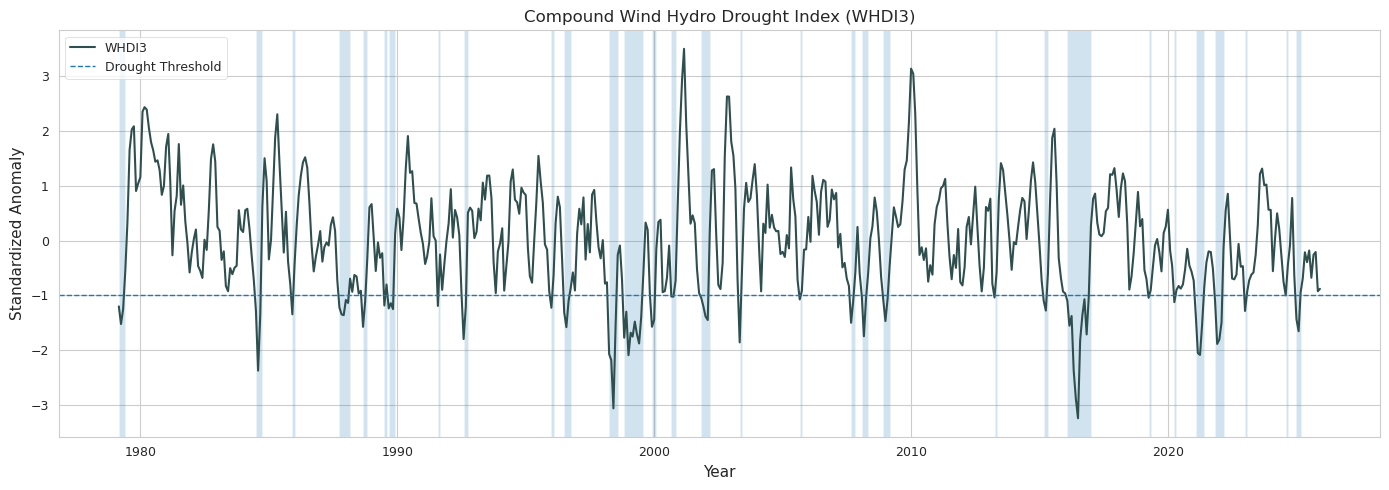

In [29]:
fig, ax = plt.subplots(figsize=(14, 5))
ax.plot(
    df_whdi.index,
    df_whdi["whdi_3"],
    color="darkslategrey",
    linewidth=1.5,
    label="WHDI3",
)
ax.axhline(
    -1,
    linestyle="--",
    linewidth=1,
    label="Drought Threshold",
)
for _, row in df_droughts.iterrows():
    ax.axvspan(
        row["start"],
        row["end"],
        alpha=0.2,
    )
ax.set_title("Compound Wind Hydro Drought Index (WHDI3)")
ax.set_ylabel("Standardized Anomaly")
ax.set_xlabel("Year")
ax.legend()

plt.tight_layout()
plt.show()

### Teleconnection Lag Correlations

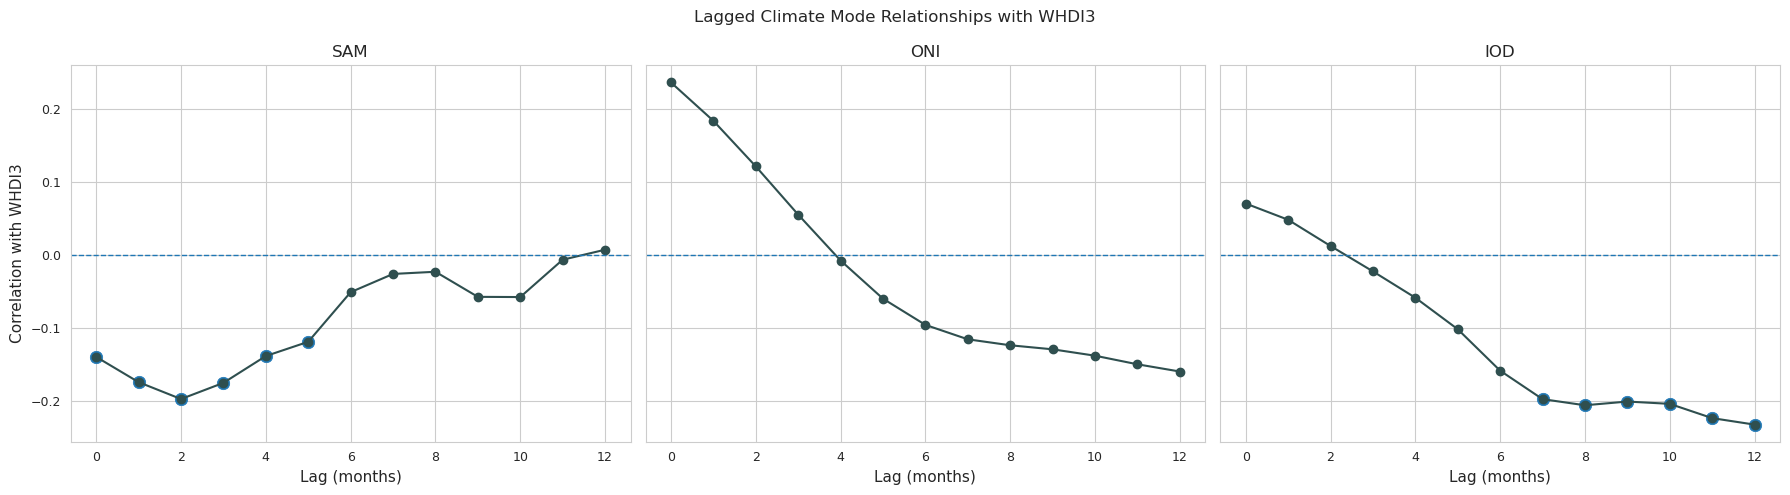

In [35]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

modes = ["sam", "oni", "iod"]

for ax, mode in zip(axes, modes):
    subset = df_lag_corr.reset_index()
    subset = subset[(subset["climate_mode"] == mode) & (subset["target"] == "whdi_3")]

    ax.plot(
        subset["lag_months"],
        subset["correlation"],
        marker="o",
        color="darkslategrey",
    )
    sig = subset[subset["significant_adj"]]
    ax.scatter(
        sig["lag_months"],
        sig["correlation"],
        s=80,
    )
    ax.axhline(0, linestyle="--", linewidth=1)
    ax.set_title(mode.upper())
    ax.set_xlabel("Lag (months)")

axes[0].set_ylabel("Correlation with WHDI3")
fig.suptitle("Lagged Climate Mode Relationships with WHDI3")

plt.tight_layout()
plt.show()

### Seasonal Correlation Heatmap

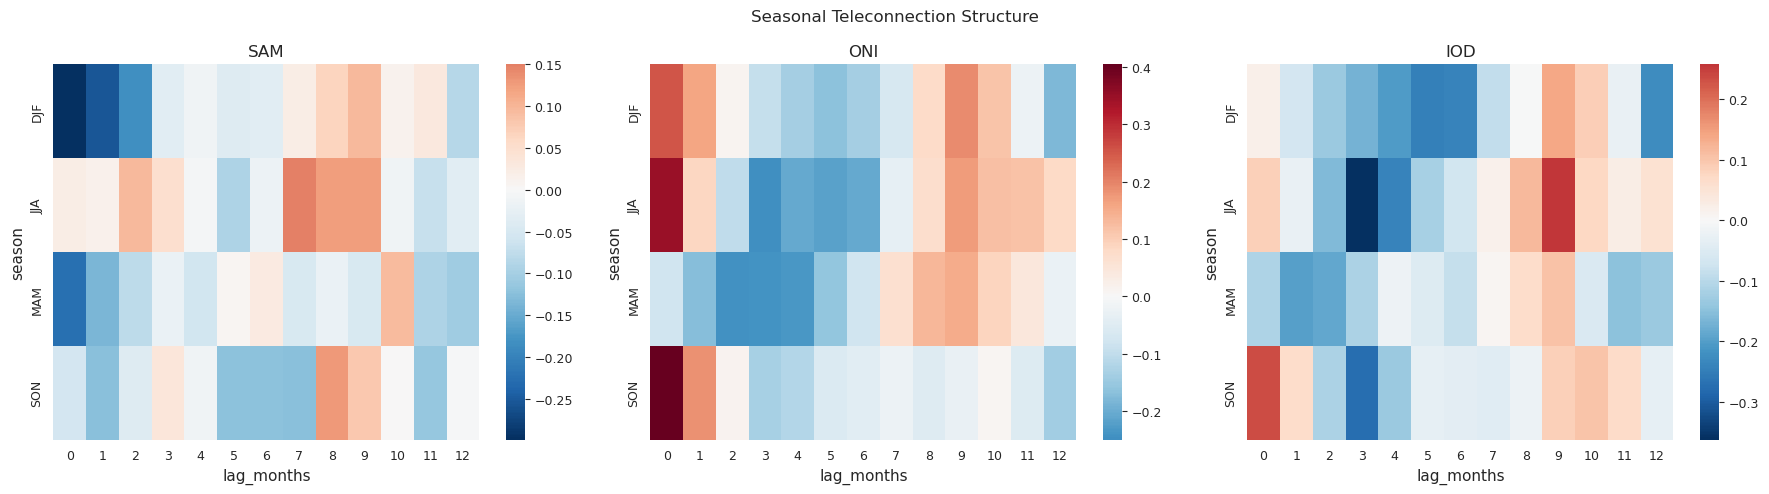

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, mode in zip(axes, modes):
    subset = df_seasonal_lag.reset_index()
    subset = subset[(subset["climate_mode"] == mode) & (subset["target"] == "whdi_3")]

    pivot = subset.pivot(
        index="season",
        columns="lag_months",
        values="correlation",
    )
    sns.heatmap(pivot, cmap="RdBu_r", center=0, ax=ax)

    ax.set_title(mode.upper())

fig.suptitle("Seasonal Teleconnection Structure")
plt.tight_layout()
plt.show()

### Forecast Skill vs Lead Time

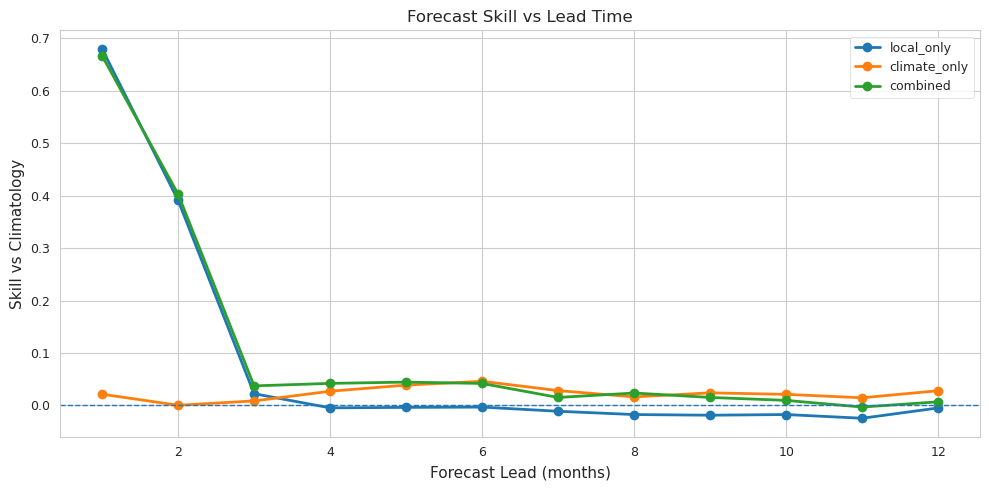

In [24]:
elastic = df_skills[
    (df_skills["model"] == "elasticnet") & (df_skills["target"] == "whdi_3")
]

skill_mean = (
    elastic.groupby(["lead", "feature_group"])["skill_vs_clim"].mean().reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))

for fg in ["local_only", "climate_only", "combined"]:
    subset = skill_mean[skill_mean["feature_group"] == fg]
    ax.plot(
        subset["lead"],
        subset["skill_vs_clim"],
        marker="o",
        linewidth=2,
        label=fg,
    )
ax.axhline(0, linestyle="--", linewidth=1)
ax.set_title("Forecast Skill vs Lead Time")
ax.set_xlabel("Forecast Lead (months)")
ax.set_ylabel("Skill vs Climatology")
ax.legend()

plt.tight_layout()
plt.show()

### Model Comparison

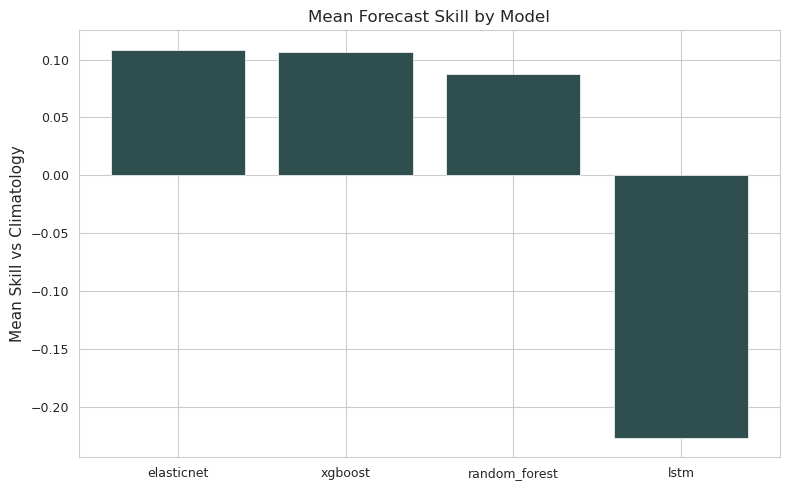

In [28]:
model_compare = (
    df_skills[
        (df_skills["target"] == "whdi_3") & (df_skills["feature_group"] == "combined")
    ]
    .groupby("model")["skill_vs_clim"]
    .mean()
    .sort_values(ascending=False)
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(
    model_compare.index,
    model_compare.values,
    color="darkslategrey",
)
ax.set_title("Mean Forecast Skill by Model")
ax.set_ylabel("Mean Skill vs Climatology")

plt.tight_layout()
plt.show()

### Elasticnet Coefficient Heatmap

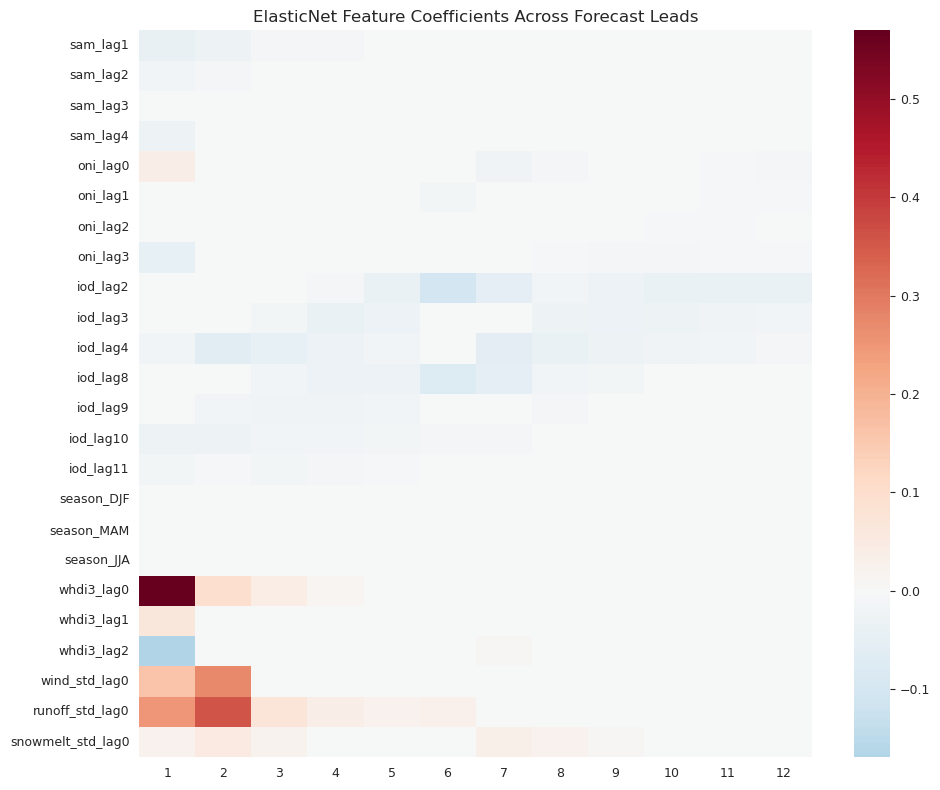

In [ ]:
df_elasticnet_coef = pd.DataFrame(coef_series)

fig, ax = plt.subplots(figsize=(10, 8))

sns.heatmap(df_elasticnet_coef, cmap="RdBu_r", center=0, ax=ax)

ax.set_title("ElasticNet Feature Coefficients Across Forecast Leads")

plt.tight_layout()
plt.show()